Экономическая идея:
Покупатели любят «круглые» веса (0.5 ct, 1.0 ct и т.д.) — «ровно каратник» воспринимается как особый статусный уровень. Поэтому камни весом около этих порогов должны стоить дороже, чем очень близкие по весу, но не попадающие в «магический» диапазон.


𝐻
0
:
𝛾
=
0
H
0
	​

:γ=0 — магические числа не дают премии.

𝐻
1
:
𝛾
>
0
H
1
	​

:γ>0 — есть положительная премия к цене за «магический» вес, при прочих равных (ceteris paribus).

In [1]:
import pandas as pd
pd.set_option("display.max_columns", None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('diamonds.csv')

df = df.rename(columns={
    'x': 'length',
    'y': 'width',
    'z': 'depth_mm',
    'depth': 'depth_%'
})

df['ln_price'] = np.log(df['price'])
df['ln_carat'] = np.log(df['carat'])
df['volume'] = df['length'] * df['width'] * df['depth_mm']

In [3]:
import numpy as np

# Окна вокруг магических чисел: 0.5, 1.0, 1.5, 2.0
conditions = [
    ((df['carat'] >= 0.48) & (df['carat'] <= 0.52)),   # вокруг 0.5
    ((df['carat'] >= 0.98) & (df['carat'] <= 1.02)),   # вокруг 1.0
    ((df['carat'] >= 1.48) & (df['carat'] <= 1.52)),   # вокруг 1.5
    ((df['carat'] >= 1.98) & (df['carat'] <= 2.02)),   # вокруг 2.0
]

df['is_magic'] = np.select(conditions, [1]*len(conditions), default=0).astype(int)

print(df['is_magic'].value_counts())


is_magic
0    39834
1    10166
Name: count, dtype: int64


<Axes: >

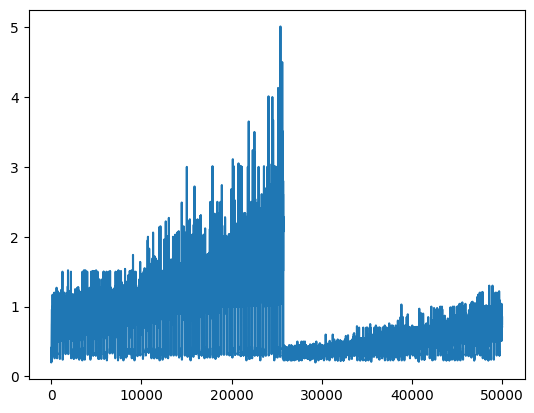

In [9]:
df['carat'].sort_index().plot()

In [5]:
df

,carat,cut,color,clarity,depth_%,table,price,length,width,depth_mm,ln_price,ln_carat,volume,is_magic
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,5.786897,-1.469676,38.202030,0
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,5.786897,-1.560648,34.505856,0
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,5.789960,-1.469676,38.076885,0
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,5.811141,-1.237874,46.724580,0
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,5.814131,-1.171183,51.917250,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50,7.921898,-0.328504,115.920000,0
49996,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61,7.921898,-0.328504,118.110175,0
49997,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56,7.921898,-0.356675,114.449728,0
49998,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74,7.921898,-0.150823,140.766120,0
